In [16]:
"""
CASE STUDY 1 — Hospital Readmission Prediction
================================================================================

Use logistic regression with L2 regularization on patient records (diagnosis codes, vitals, prior visits) to predict 30-day readmission risk. Evaluate with ROC-AUC and discuss clinical cost of false negatives vs. false positives.

"""


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt



In [17]:

# ============================================================================
# STEP 1: DATA LOAD
# ============================================================================
train_df = pd.read_csv("train_df.csv")
test_df = pd.read_csv("test_df.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("sample_submission shape:", sample_sub.shape)


train_df shape: (5000, 8)
test_df shape: (2000, 7)
sample_submission shape: (2000, 2)


In [18]:

# ============================================================================
# STEP 2: PREPROCESSING -> DATA CLEANING
# ============================================================================
print("\n--- Cleaning train_df ---")
print("Rows before:", len(train_df))
print("Missing values per column:\n", train_df.isna().sum())

n_dupes = train_df.duplicated().sum()
print("Duplicate rows:", n_dupes)
train_df = train_df.drop_duplicates().reset_index(drop=True)
print("Rows after dropping duplicates:", len(train_df))
print("Readmission rate:", train_df["readmitted"].mean())

# We do NOT drop duplicates from test_df -- every row in test_df needs a
# prediction so it lines up with sample_submission.csv row for row.
print("\n--- Checking test_df ---")
print("Missing values per column:\n", test_df.isna().sum())
print("Duplicate rows in test_df (kept as-is):", test_df.duplicated().sum())

# Quick EDA: how correlated is each feature with the target?
# If everything is close to 0, no model will predict well -- good to know
# BEFORE training instead of being confused by a low ROC-AUC later.
train_encoded_for_corr = pd.get_dummies(train_df, columns=["gender", "primary_diagnosis", "discharge_to"])
correlations = train_encoded_for_corr.corr()["readmitted"].drop("readmitted").sort_values()
print("\n--- Feature <-> target correlation ---")
print(correlations)


--- Cleaning train_df ---
Rows before: 5000
Missing values per column:
 age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
readmitted           0
dtype: int64
Duplicate rows: 4
Rows after dropping duplicates: 4996
Readmission rate: 0.18815052041633307

--- Checking test_df ---
Missing values per column:
 age                  0
gender               0
primary_diagnosis    0
num_procedures       0
days_in_hospital     0
comorbidity_score    0
discharge_to         0
dtype: int64
Duplicate rows in test_df (kept as-is): 1

--- Feature <-> target correlation ---
discharge_to_Skilled Nursing Facility   -0.020842
gender_Male                             -0.015607
primary_diagnosis_Hypertension          -0.012922
days_in_hospital                        -0.010001
primary_diagnosis_Heart Disease         -0.006827
primary_diagnosis_COPD                  -0.003628
num_procedures             

In [19]:

# ============================================================================
# STEP 3: ML MODEL (Logistic Regression: with L2 vs without)
# ============================================================================
target = "readmitted"
categorical_features = ["gender", "primary_diagnosis", "discharge_to"]
numeric_features = ["age", "num_procedures", "days_in_hospital", "comorbidity_score"]

X = train_df[numeric_features + categorical_features]
y = train_df[target]

# Split train_df itself into an internal train/validation set, since
# test_df.csv has no labels to check ROC-AUC / False Negatives against.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("\nInternal train size:", len(X_train), " validation size:", len(X_val))

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model_with_l2 = LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=42)
model_no_reg = LogisticRegression(penalty=None, max_iter=1000, random_state=42)

pipeline_l2 = Pipeline([("preprocessor", preprocessor), ("classifier", model_with_l2)])
pipeline_no_reg = Pipeline([("preprocessor", preprocessor), ("classifier", model_no_reg)])



Internal train size: 3747  validation size: 1249


In [20]:

# ============================================================================
# STEP 4: TRAINING
# ============================================================================
pipeline_l2.fit(X_train, y_train)
pipeline_no_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'num_procedures',
                                                   'days_in_hospital',
                                                   'comorbidity_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'primary_diagnosis',
                                                   'discharge_to'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty=None,
                                    random_state=42))])

In [21]:


# ============================================================================
# STEP 5: ROC-AUC EVALUATION
# ============================================================================
y_prob_l2 = pipeline_l2.predict_proba(X_val)[:, 1]
y_prob_no_reg = pipeline_no_reg.predict_proba(X_val)[:, 1]

auc_l2 = roc_auc_score(y_val, y_prob_l2)
auc_no_reg = roc_auc_score(y_val, y_prob_no_reg)

print("\n===== ROC-AUC =====")
print("With L2:      ", round(auc_l2, 4))
print("Without reg.: ", round(auc_no_reg, 4))



===== ROC-AUC =====
With L2:       0.4918
Without reg.:  0.4917



===== Logistic Regression WITH L2 (threshold = 0.5 ) =====
Confusion matrix [[TN, FP], [FN, TP]]:
[[1014    0]
 [ 235    0]]
False Negatives (missed readmissions): 235
False Positives (unnecessary follow-up): 0
True Positives (correctly flagged):      0
True Negatives (correctly cleared):      1014
                precision    recall  f1-score   support

Not Readmitted       0.81      1.00      0.90      1014
    Readmitted       0.00      0.00      0.00       235

      accuracy                           0.81      1249
     macro avg       0.41      0.50      0.45      1249
  weighted avg       0.66      0.81      0.73      1249

Clinical cost discussion:
- A False Negative means a patient the model called 'safe' who
  actually gets readmitted -> a missed chance for follow-up care.
- A False Positive just means an extra follow-up for someone who
  didn't need it -> costs time/money but not health.
- Because FN is usually the costlier mistake, hospitals often lower
  the threshold bel

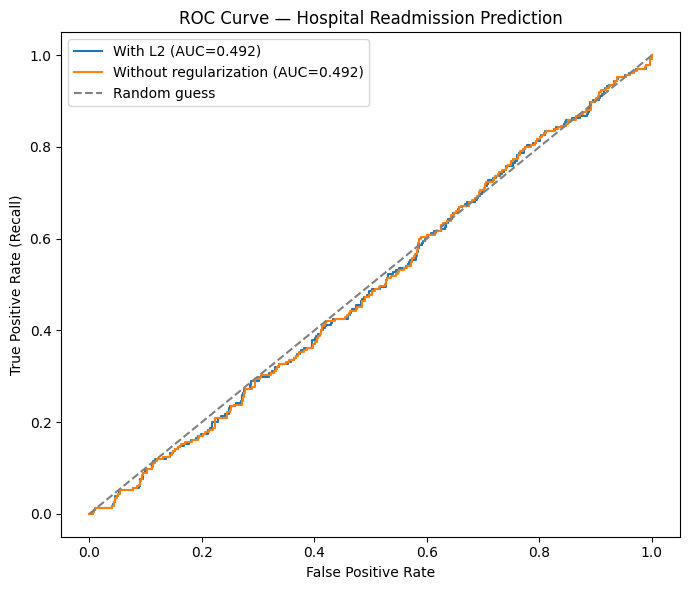

In [22]:

# ============================================================================
# STEP 6: FALSE NEGATIVE ANALYSIS
# ============================================================================
threshold = 0.5
y_pred_l2 = (y_prob_l2 >= threshold).astype(int)

cm = confusion_matrix(y_val, y_pred_l2)
tn, fp, fn, tp = cm.ravel()

print("\n===== Logistic Regression WITH L2 (threshold =", threshold, ") =====")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
print("False Negatives (missed readmissions):", fn)
print("False Positives (unnecessary follow-up):", fp)
print("True Positives (correctly flagged):     ", tp)
print("True Negatives (correctly cleared):     ", tn)
print(classification_report(y_val, y_pred_l2, target_names=["Not Readmitted", "Readmitted"], zero_division=0))

print("Clinical cost discussion:")
print("- A False Negative means a patient the model called 'safe' who")
print("  actually gets readmitted -> a missed chance for follow-up care.")
print("- A False Positive just means an extra follow-up for someone who")
print("  didn't need it -> costs time/money but not health.")
print("- Because FN is usually the costlier mistake, hospitals often lower")
print("  the threshold below 0.5 to catch more true positives.")

# Plot ROC curve for both models
plt.figure(figsize=(7, 6))
fpr_l2, tpr_l2, _ = roc_curve(y_val, y_prob_l2)
fpr_nr, tpr_nr, _ = roc_curve(y_val, y_prob_no_reg)
plt.plot(fpr_l2, tpr_l2, label=f"With L2 (AUC={auc_l2:.3f})")
plt.plot(fpr_nr, tpr_nr, label=f"Without regularization (AUC={auc_no_reg:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Hospital Readmission Prediction")
plt.legend()
plt.tight_layout()
plt.savefig("hospital_roc_curve_simple.png", dpi=150)
print("\nROC curve saved to hospital_roc_curve_simple.png")


#FINAL STEP :
####retrain on ALL of train_df.csv, predict on test_df.csv,save submission.csv in the exact format sample_submission.csv shows.


In [23]:
final_pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", model_with_l2)])
final_pipeline.fit(X, y)

X_test = test_df[numeric_features + categorical_features]
test_pred_prob = final_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_pred_prob >= 0.5).astype(int)

submission = sample_sub.copy()
submission["readmitted"] = test_pred
submission.to_csv("submission_simple.csv", index=False)
print("\nSaved predictions to submission_simple.csv")
print(submission.head())


Saved predictions to submission_simple.csv
   Patient_ID  readmitted
0           1           0
1           2           0
2           3           0
3           4           0
4           5           0
